In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [167]:
transform =  transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
transform2=transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.CIFAR10(root='./data',train=True,transform=transform2,download=True)
test_dataset=datasets.CIFAR10(root='./data',train=False,transform=transform2,download=True)
test_dataset_visualizer=datasets.CIFAR10(root='./data',train=False,transform=transforms.Compose([transforms.ToTensor()]),download=True)
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=1000)
test_visualizer_loader=DataLoader(test_dataset_visualizer,batch_size=1000)

In [168]:
def train_model(model,train_loader,test_loader,optimizer,loss_fn,epochs=5):
  for epoch in range(epochs):
    model.train()
    total_loss=0
    for x,y in train_loader:
      x,y=x.to(device),y.to(device)
      optimizer.zero_grad()
      logits=model(x)
      loss=loss_fn(logits,y)
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()
    print(f"Epoch {epoch+1}")
    print(f"Loss : {total_loss:.4f}")
    print("Training Accuracy")
    test_model(model,train_loader)
    print("Testing Accuracy")
    test_model(model,test_loader)
def test_model(model,test_loader):
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for x,y in test_loader:
      x,y=x.to(device),y.to(device)
      logits=model(x)
      pred=logits.argmax(dim=1)
      correct+=(pred==y).sum().item()
      total+=y.size(0)
  print(f"Accuracy: {100*correct/total :.2f}")


In [169]:
model=nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(32,32,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(32,64,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(64,64,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.3),
    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.Conv2d(128,128,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Dropout(0.4),
    nn.Flatten(),
    nn.Linear(2048,128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128,10)
)
model=model.to(device)
optimizer=optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-3)
loss_fn=nn.CrossEntropyLoss()
train_model(model,train_loader,test_loader,optimizer,loss_fn,15)
test_model(model,test_loader)

Epoch 1
Loss : 1472.4917
Training Accuracy
Accuracy: 42.17
Testing Accuracy
Accuracy: 42.70
Epoch 2
Loss : 1167.4798
Training Accuracy
Accuracy: 52.43
Testing Accuracy
Accuracy: 51.81
Epoch 3
Loss : 1036.6656
Training Accuracy
Accuracy: 58.16
Testing Accuracy
Accuracy: 57.19
Epoch 4
Loss : 952.3648
Training Accuracy
Accuracy: 63.09
Testing Accuracy
Accuracy: 62.13
Epoch 5
Loss : 879.7464
Training Accuracy
Accuracy: 65.38
Testing Accuracy
Accuracy: 64.47
Epoch 6
Loss : 825.3491
Training Accuracy
Accuracy: 69.37
Testing Accuracy
Accuracy: 66.98
Epoch 7
Loss : 783.3699
Training Accuracy
Accuracy: 72.85
Testing Accuracy
Accuracy: 70.51
Epoch 8
Loss : 746.5240
Training Accuracy
Accuracy: 72.18
Testing Accuracy
Accuracy: 69.69
Epoch 9
Loss : 721.5712
Training Accuracy
Accuracy: 73.33
Testing Accuracy
Accuracy: 70.37
Epoch 10
Loss : 702.4353
Training Accuracy
Accuracy: 74.24
Testing Accuracy
Accuracy: 71.09
Epoch 11
Loss : 684.5813
Training Accuracy
Accuracy: 74.43
Testing Accuracy
Accuracy: 

In [170]:
torch.save(model.state_dict(),"model.pth")

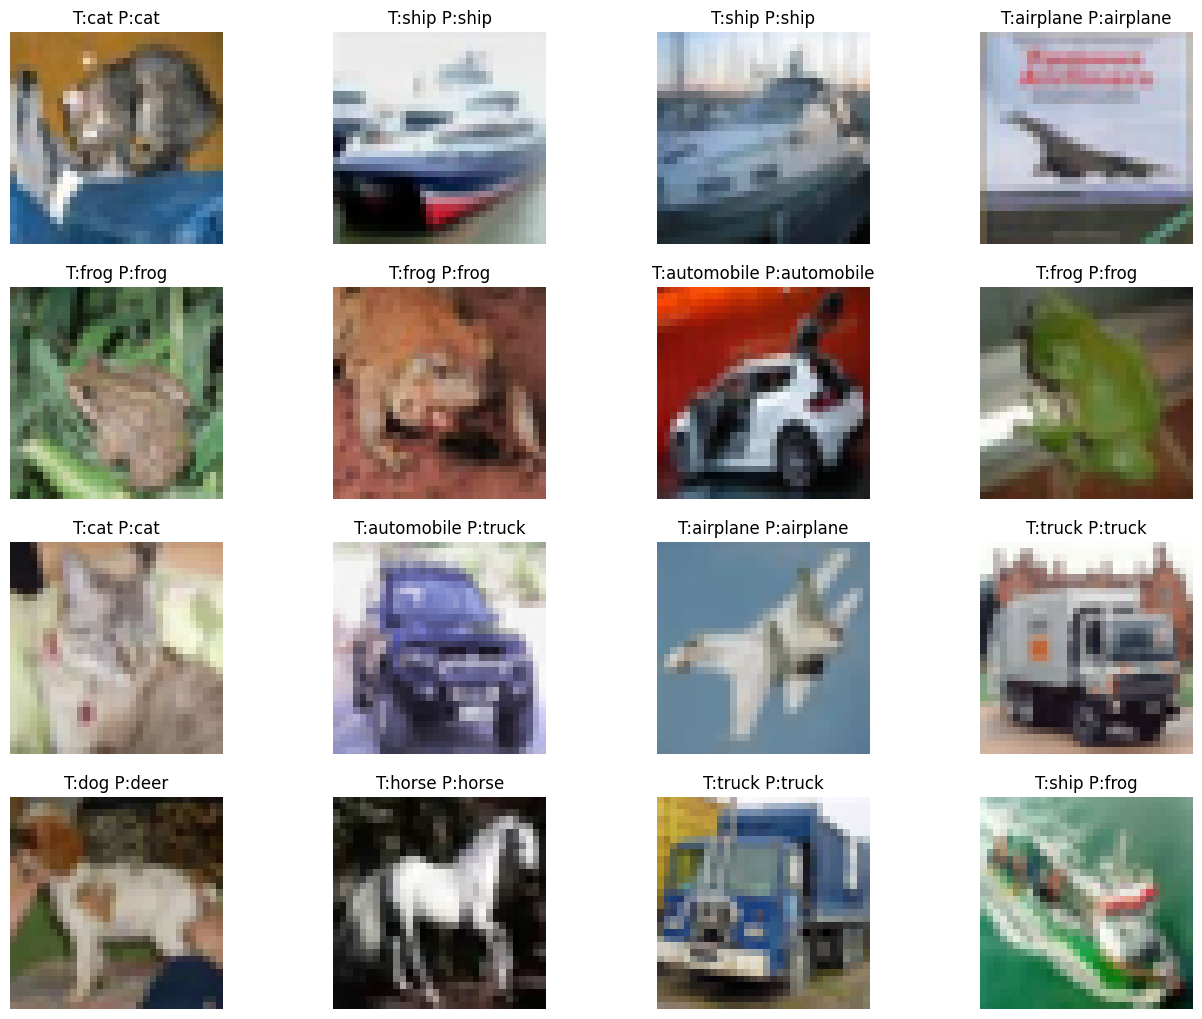

In [172]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]
def visualize(model,visualizer_loader, loader, n=5):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    preds = model(x).argmax(dim=1)
    x, y = next(iter(visualizer_loader))
    x, y = x.to(device), y.to(device)
    plt.figure(figsize=(16,16))
    for i in range(n):
        plt.subplot(n//4+1, 4, i+1)
        plt.imshow(x[i].cpu().squeeze().permute(1,2,0))
        plt.title(f"T:{class_names[y[i]]} P:{class_names[preds[i]]}")
        plt.axis('off')
    plt.show()
visualize(model,test_loader,test_loader,16)

In [207]:
def fgsm_attack(model,test_loader,epsilon,print_images=False,no_of_images=-1):
    model.eval()
    correct=0
    total=0
    total_printed_images=0
    for x,y in test_loader:
        x,y=x.to(device),y.to(device)
        vis_x,vis_y=next(iter(test_visualizer_loader))
        total+=y.size(0)
        model.zero_grad()
        x.requires_grad=True
        logits = model(x)
        preds=logits.argmax(dim=1)
        loss_fn=nn.CrossEntropyLoss()
        loss=loss_fn(logits,y)
        loss.backward()
        new_x=x+x.sign()*epsilon
        new_x=new_x.clip(0,1)
        final_preds=model(new_x).argmax(dim=1)
        correct+=(final_preds==y).sum().item()
        if print_images==True and total_printed_images<no_of_images:
            for i in range(x.shape[0]):
                if total_printed_images==no_of_images:
                    break
                if preds[i].item()!=final_preds[i].item() and preds[i].item()==y[i].item():
                    total_printed_images+=1
                    plt.figure(figsize=(4,4))
                    plt.subplot(1,2,1)
                    plt.imshow(x[i].detach().cpu().squeeze().permute(1,2,0))
                    plt.title(f"Actual = {class_names[vis_y[i]]} \n pred before attack \n{class_names[preds[i]]}")
                    plt.subplot(1,2,2)
                    plt.imshow(new_x[i].detach().cpu().squeeze().permute(1,2,0))
                    plt.title(f"pred after attack={class_names[final_preds[i]]}")
                    
                    plt.show()
                    
        

    print(f"Epsilon : {epsilon} , Accuracy : {100*correct/total}")
        
    

In [211]:
for epsilon in [0,0.1,0.15,0.20,0.25,0.30,0.35,0.40,0.45]:
    fgsm_attack(model,test_loader,epsilon)

Epsilon : 0 , Accuracy : 75.42
Epsilon : 0.1 , Accuracy : 74.78
Epsilon : 0.15 , Accuracy : 74.09
Epsilon : 0.2 , Accuracy : 73.32
Epsilon : 0.25 , Accuracy : 72.64
Epsilon : 0.3 , Accuracy : 71.3
Epsilon : 0.35 , Accuracy : 69.18
Epsilon : 0.4 , Accuracy : 66.64
Epsilon : 0.45 , Accuracy : 62.69


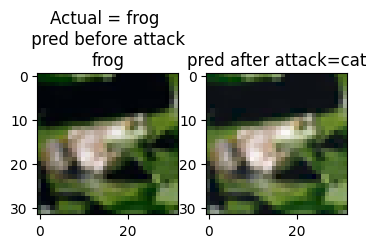

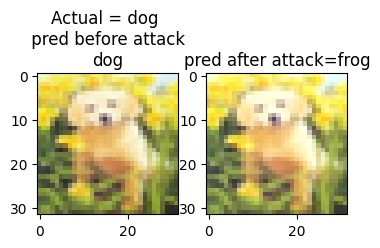

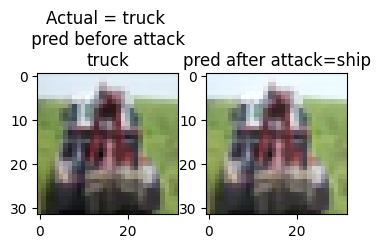

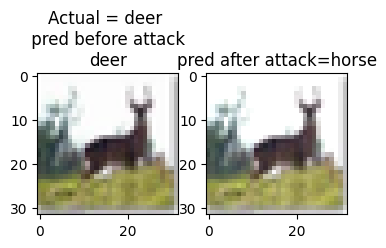

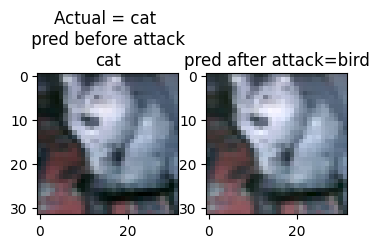

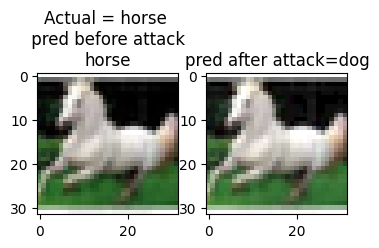

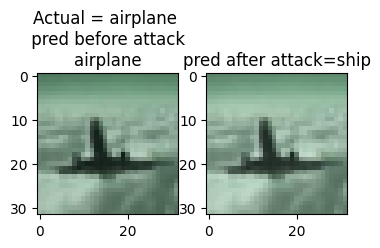

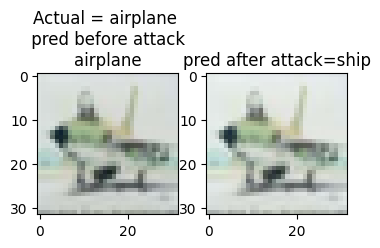

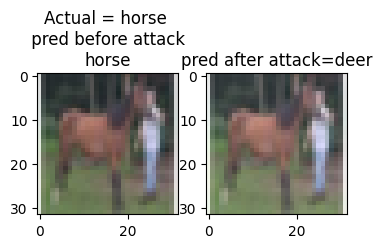

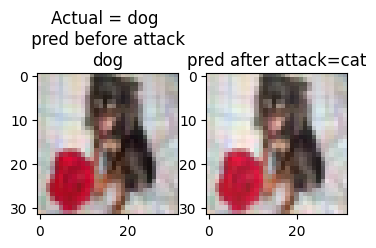

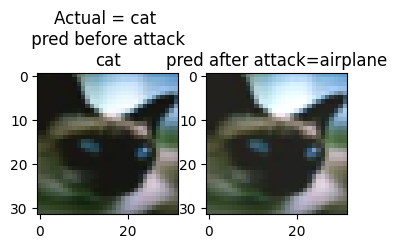

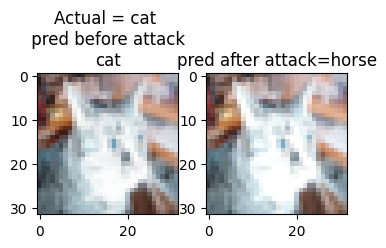

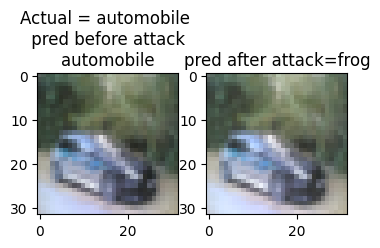

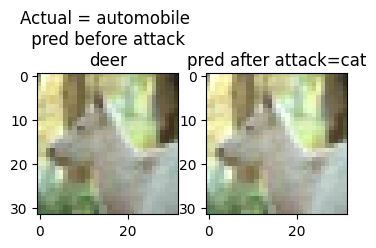

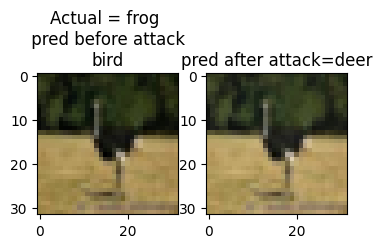

Epsilon : 0.05 , Accuracy : 75.06


In [315]:
fgsm_attack(model,test_loader,0.05,print_images=True,no_of_images=15)

In [56]:
imagepath_1="https://drive.google.com/file/d/1QFmNQlqsDp2O-1yHjGAYcJvGC9zfIAgp/view?usp=sharing"

In [58]:
import gdown

file_id = "1QFmNQlqsDp2O-1yHjGAYcJvGC9zfIAgp"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "image.jpg", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1QFmNQlqsDp2O-1yHjGAYcJvGC9zfIAgp
To: /kaggle/working/image.jpg
100%|██████████| 159k/159k [00:00<00:00, 78.0MB/s]


'image.jpg'

In [69]:
from PIL import Image
import numpy as np

img = Image.open("image.jpg").convert("RGB")
img_np = np.array(img)
img_np=img_np.astype(np.int64)
print(img_np.shape, img_np.dtype)

(499, 500, 3) int64


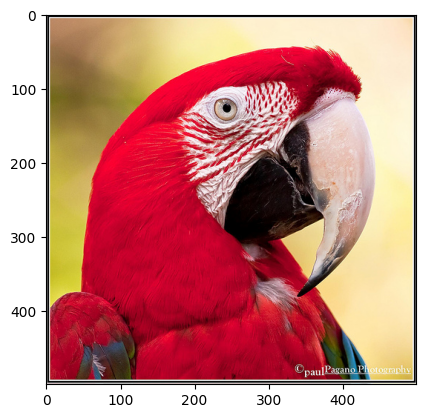

In [70]:
plt.imshow(img_np)

In [116]:
def test_image(model,img):
    model.eval()
    # img=torch.from_numpy(img).to(torch.float32)
    img = transform(img)
    resize_transform = transforms.Resize(size=(32,32))
    img=resize_transform(img)
    img=img.to(device)
    img.unsqueeze(0)
    img=img.unsqueeze(dim=0)
    # print(img.shape)
    pred=torch.argmax(model(img),dim=1)
    plt.imshow(img.cpu().squeeze().permute(1,2,0))
    plt.title(f"pred={class_names[pred[0].item()]}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


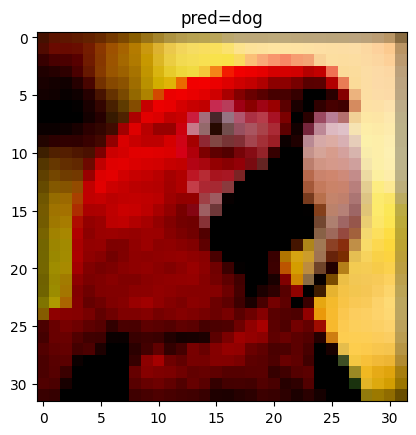

In [117]:
test_image(model,img)

In [214]:
import torchvision.models as models


In [220]:
net = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

net.eval()

im_orig = Image.open("image.jpg")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

im = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])(im_orig)

def clip_tensor(A, minv, maxv):
  A = torch.max(A, minv*torch.ones(A.shape))
  A = torch.min(A, maxv*torch.ones(A.shape))
  return A

clip = lambda x: clip_tensor(x, 0, 255)

tf = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=list(map(lambda x: 1/x, std))),
    transforms.Normalize(mean=list(map(lambda x: -x, mean)), std=[1,1,1]),
    transforms.Lambda(clip),
    transforms.ToPILImage(),
    transforms.CenterCrop(224)
])

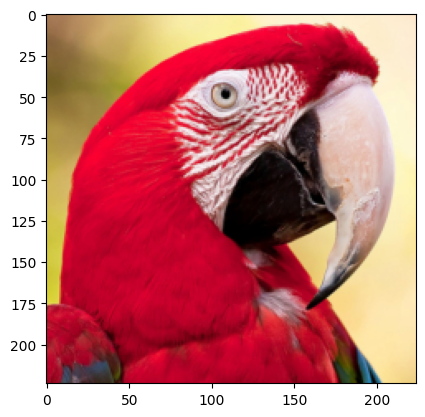

In [221]:
plt.imshow(tf(im))

In [311]:
def deepfool(model, im, step=0.01, max_iter=10000):
    model.eval()

    im = im.clone().detach().to(device)
    im_orig = im.clone().detach()

    loss_fn = nn.CrossEntropyLoss()

    im.requires_grad_(True)
    orig_logits = model(im)
    orig_pred = orig_logits.argmax(dim=1)
    pred = orig_pred.clone()

    i = 0
    while pred.item() == orig_pred.item() and i < max_iter:
        i += 1

        model.zero_grad()
        if im.grad is not None:
            im.grad.zero_()

        logits = model(im)
        loss = loss_fn(logits, orig_pred)
        loss.backward()

        with torch.no_grad():
            grad = im.grad
            grad = grad / (grad.norm() + 1e-8)
            im = im + step * grad.clip(0,1)
            # im = im.clamp(-1, 1)   # adjust if needed

        im.requires_grad_(True)
        pred = model(im).argmax(dim=1)

    noise = im - im_orig

    return orig_pred.item(), pred.item(), im_orig, im, noise


In [312]:
orig_pred, adv_pred, im_orig, im_adv,noise = deepfool(net, im.unsqueeze(0))


In [313]:
print(orig_pred, adv_pred)

88 90


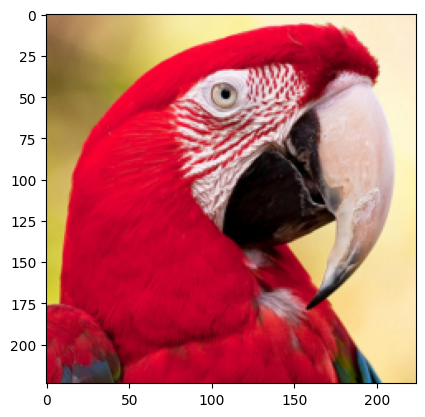

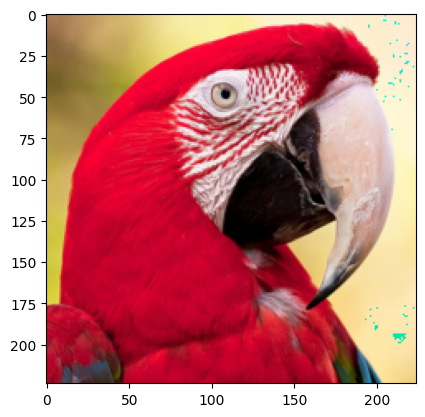

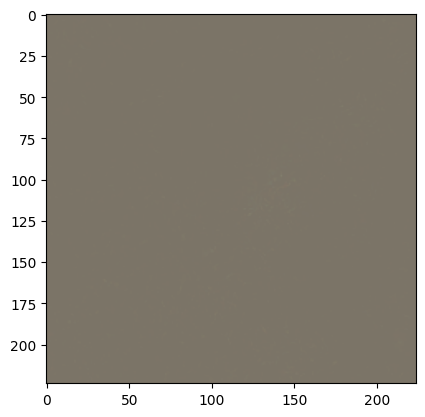

In [314]:
plt.imshow(tf(im_orig.squeeze(dim=0).cpu()))
plt.show()
plt.imshow(tf(im_adv.squeeze(dim=0).cpu()))
plt.show()
plt.imshow(tf(noise.squeeze(dim=0).cpu()))
plt.show()

In [ ]:
def deepfool(model,im):
    im_orig = im.clone().detach()
    noise=im
    noise-=im
    im.require_grad(True)
    model.eval()
    model.zero_grad()
    loss_fn=nn.CrossEntropyLoss()
    orig_logits=model(im)
    orig_pred=torch.argmax(orig_logits,dim=1)
    pred=orig_pred
    im.grad=None
    i=0
    while pred.item()==orig_pred.item():
        i+=1
        im.requires_grad_(True)
        logits=model(im)
        loss=loss_fn(logits,orig_pred)
        loss.backward()
        with torch.no_grad():
            im+=im.grad*0.01
        im.grad=None
        pred=torch.argmax(logits,dim=1)
        print(i)
    return orig_pred,pred,